Dataset Loaded Successfully
Removing high-correlation leaky features: ['Provider_Patient_Distance_Miles', 'Number_of_Previous_Claims_Provider', 'Number_of_Procedures', 'Number_of_Previous_Claims_Patient']
Training Model...

--- Metrics Table ---
      Metric   Score
0   Accuracy  0.9615
1  Precision  0.9793
2     Recall  0.9423
3   F1 Score  0.9604


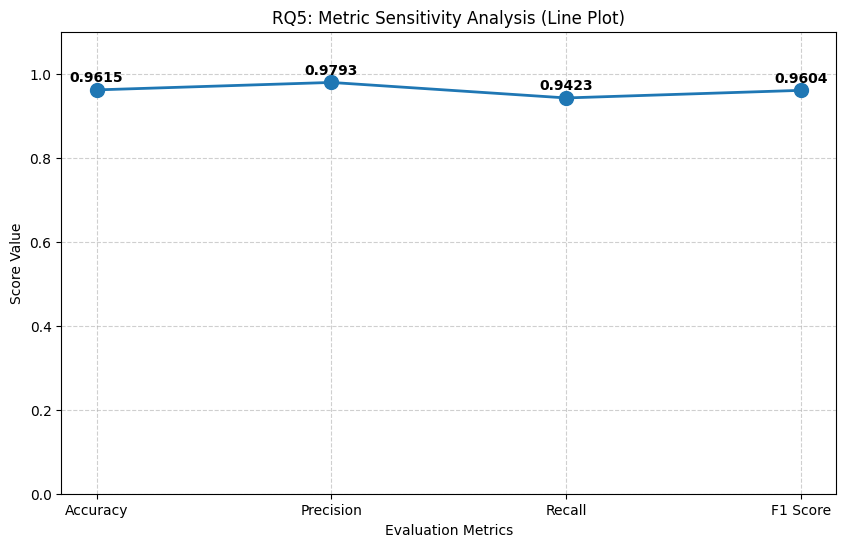


Process Completed. Line plot and CSV saved.


In [3]:
# ============================================
# RQ5: Metric Sensitivity Analysis
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier

# --------------------------------------------
# Step 1: Load and Clean
# --------------------------------------------

df = pd.read_csv(r"C:\Users\dheer\Desktop\ML\cleaned_dataset.csv")

df = df.drop_duplicates()

print("Dataset Loaded Successfully")

# --------------------------------------------
# Step 2: Identification & Leakage Removal
# --------------------------------------------

target_col = 'Is_Fraudulent'

# Drop direct identifiers
ids_to_drop = [
    'Patient_ID',
    'Policy_Number',
    'Claim_ID',
    'Hospital_ID',
    'Unnamed: 0'
]

df = df.drop(
    columns=[c for c in ids_to_drop if c in df.columns]
)

# Remove highly correlated leaky features
numeric_df = df.select_dtypes(include=[np.number])

correlations = (
    numeric_df.corr()[target_col]
    .abs()
    .sort_values(ascending=False)
)

leaky_features = correlations[
    correlations > 0.75
].index.tolist()

if target_col in leaky_features:
    leaky_features.remove(target_col)

print(f"Removing high-correlation leaky features: {leaky_features}")

# Features and Target
X = df.drop(columns=[target_col] + leaky_features)

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

y = df[target_col]

# --------------------------------------------
# Step 3: Train-Test Split (Stratified)
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------
# Step 4: Train Regularized Model
# --------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

print("Training Model...")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# --------------------------------------------
# Step 5: Metrics Table
# --------------------------------------------

metrics_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ]
})

print("\n--- Metrics Table ---")
print(metrics_df.round(4))

# --------------------------------------------
# Step 6: Create Line Plot
# --------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    metrics_df['Metric'],
    metrics_df['Score'],
    marker='o',
    linewidth=2,
    markersize=10
)

# Add value labels
for i, score in enumerate(metrics_df['Score']):
    plt.text(
        i,
        score + 0.02,
        f'{score:.4f}',
        ha='center',
        fontweight='bold'
    )

plt.ylim(0, 1.1)

plt.xlabel('Evaluation Metrics')
plt.ylabel('Score Value')

plt.title('RQ5: Metric Sensitivity Analysis (Line Plot)')

plt.grid(True, linestyle='--', alpha=0.6)

# --------------------------------------------
# Step 7: Save Results
# --------------------------------------------

plt.savefig(
    r"C:\Users\dheer\Desktop\ML\RQ5_line_plot.png",
    bbox_inches='tight'
)

metrics_df.to_csv(
    r"C:\Users\dheer\Desktop\ML\RQ5_table.csv",
    index=False
)

plt.show()

print("\nProcess Completed. Line plot and CSV saved.")